In [9]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mis_dro.likelihood import cholesky_param_to_covariance
from mis_dro.bayes_conjugates import *
from mis_dro.dataset import portfolio_dataset
from mis_dro.preprocessing import normalise_by_dimension

In [10]:
dgp = "DowJones"
replication = 0
normalise = False
npl_uuid = "83aa670b-a7d2-4c4c-8472-3656114be630"
samples_dir = Path("/dcs/large/u1508153/misdro/mmd_portfolio_debug/2025_01_15_mmd_portfolio")

mmc2_dir = Path("/dcs/pg20/u1508153/datasets/misdro/mmc2")
assert mmc2_dir.exists()
# returns_df = pd.read_excel(mmc2_dir / "Datasets" / dgp / f"{dgp}.xlsx", sheet_name="Assets_Returns", header=None)
data, data_eval = portfolio_dataset(dgp, replication, mmc2_dir)

npl_settings_df = pd.read_csv(samples_dir / "npl_settings.csv").set_index("npl_uuid")

if normalise:
    data = normalise_by_dimension(data)

portfolio_npl_samples_csv = Path(samples_dir / npl_uuid / f"npl_sample_{replication}.csv")
# portfolio_npl_samples_csv = Path(f"/dcs/large/u1508153/misdro/mmd_portfolio_samples/8c01253f-8d7b-471c-a7b3-3516b2ddef2e/npl_sample_{replication}.csv")

npl_df = pd.read_csv(portfolio_npl_samples_csv, index_col=False, header=None)
npl_samples = npl_df.values

num_posterior_samples = npl_samples.shape[0]
dim = data.shape[1]

settings = npl_settings_df.loc[npl_uuid]
settings

contamination                            0.0
dataset                            portfolio
dgp                                 DowJones
dim                                       28
eta                                      0.1
inference                            npl_mmd
lengthscale                             -1.0
likelihood               multivariate_normal
normalise                               True
num_observations                          52
num_posterior_samples                     90
num_replications                         109
posterior                                npl
Name: 83aa670b-a7d2-4c4c-8472-3656114be630, dtype: object

In [11]:
# Bayes posterior
posterior = "normal_inverse_wishart"
theta_prior = default_prior_params(posterior, dim=dim)
theta_posterior = get_posterior_params(posterior, data, theta_prior)
mu_post, _, iota_post, Psi_post = theta_posterior

In [12]:
# NPL posterior with full covariance
npl_means = np.zeros((num_posterior_samples, dim))
npl_covs = np.zeros((num_posterior_samples, dim, dim))
for i in range(num_posterior_samples):
    npl_means[i] = npl_samples[i,:dim]
    npl_covs[i] = cholesky_param_to_covariance(dim, npl_samples[i,dim:])
mu_post

array([-2.50050231e-17, -1.20024111e-17,  4.00080369e-18,  2.20044203e-17,
        2.40048222e-17,  1.50030138e-17,  4.00080369e-18, -2.20044203e-17,
       -4.00080369e-18,  1.15023106e-17, -6.00120554e-18,  1.00020092e-17,
       -1.10022102e-17, -1.70034157e-17,  1.40028129e-17,  2.00040185e-17,
        1.72534659e-17,  1.00020092e-17, -6.00120554e-18,  1.40028129e-17,
        9.00180831e-18, -8.00160738e-18,  3.05061282e-17, -3.00060277e-17,
        2.92187602e-17, -3.25065300e-17, -2.00040185e-18, -4.00080369e-18])

In [13]:
mean_npl_mean = npl_means.mean(axis=0)
mean_npl_cov = npl_covs.mean(axis=0)
mean_npl_mean

array([ 0.04697413,  0.01020907,  0.06452831,  0.02067866,  0.01722731,
        0.08146592, -0.00037707,  0.03850433,  0.02126589, -0.01161089,
        0.07617128,  0.03054243,  0.03590382,  0.00455552,  0.01755415,
        0.06001654, -0.005791  ,  0.02172209,  0.07669789,  0.02347286,
        0.05077812, -0.01309832,  0.042178  ,  0.05493085, -0.02137539,
       -0.04478103, -0.01892697,  0.05379643])

In [14]:
mean_npl_mean - mu_post

array([ 0.04697413,  0.01020907,  0.06452831,  0.02067866,  0.01722731,
        0.08146592, -0.00037707,  0.03850433,  0.02126589, -0.01161089,
        0.07617128,  0.03054243,  0.03590382,  0.00455552,  0.01755415,
        0.06001654, -0.005791  ,  0.02172209,  0.07669789,  0.02347286,
        0.05077812, -0.01309832,  0.042178  ,  0.05493085, -0.02137539,
       -0.04478103, -0.01892697,  0.05379643])

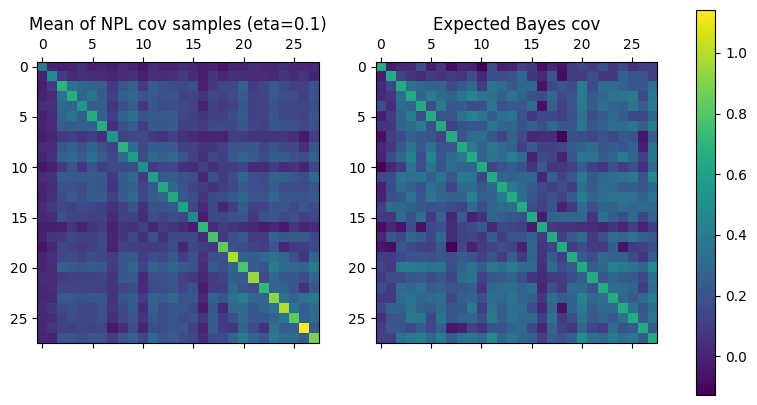

In [15]:
# Create a figure and axes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

bayes_cov = (1.0 / float(iota_post)) * Psi_post
vmin = np.min([bayes_cov, mean_npl_cov])
vmax = np.max([bayes_cov, mean_npl_cov])

# Plot the first matrix
c1 = ax1.matshow(mean_npl_cov, cmap='viridis', vmin=vmin, vmax=vmax)
ax1.set_title(f"Mean of NPL cov samples (eta={settings['eta']})")

# Plot the second matrix
c2 = ax2.matshow(bayes_cov, cmap='viridis', vmin=vmin, vmax=vmax)
ax2.set_title('Expected Bayes cov')

# Create a shared colorbar
cbar = fig.colorbar(c1, ax=[ax1, ax2], orientation='vertical')

fig.show()


In [16]:
(data[:,0] - data[:,0].mean())/data[:,0].std()

array([-0.99212097, -1.31579248,  0.90817367,  0.86886933,  0.31128407,
       -1.87084319, -0.2469046 , -0.45146716, -1.29371375,  1.77273343,
        1.5885485 , -0.4049069 , -0.71339809,  0.02115891,  0.19904105,
       -0.71999376, -0.46983352, -1.71451998,  0.29579638,  0.24009729,
        0.61011164, -0.16032682,  1.09697296,  1.04919253, -0.2032234 ,
        1.95085094, -0.32042172, -0.84029382,  0.82473143, -2.72310566,
        2.03668643, -0.76887649,  0.44941153,  0.30528722,  1.11269206,
        0.28952799, -0.23754102, -0.44433597, -0.11681161,  0.13601221,
        1.14678505,  0.55611332, -0.47144339,  0.43774949, -0.74517394,
       -0.55043469, -0.45511093,  0.12096326,  0.33341069, -2.20673911,
        1.20050551,  0.57462607])